# Context Window Size vs LLM Call Duration Experiment

This notebook provides an interactive interface for running context window scaling experiments across multiple LLM models.

## Overview
- **Goal**: Measure how LLM response time scales with context window size
- **Models**: 6 models via ORQ proxy (OpenAI, Google, Anthropic)
- **Token Sizes**: Powers of 10 from 10¹ to 10⁶ tokens
- **Output**: Performance analysis, visualizations, and scaling patterns

## Models Tested
1. **OpenAI GPT-5 Mini** (`openai/gpt-5-mini`)
2. **OpenAI GPT-4.1 Nano** (`openai/gpt-4.1-nano`)
3. **Google Gemini 2.5 Flash** (`google-ai/gemini-2.5-flash`)
4. **Google Gemini 2.0 Flash Lite** (`google-ai/gemini-2.0-flash-lite-001`)
5. **Claude Sonnet 4** (`azure/claude-sonnet-4-20250514`)
6. **Claude Haiku** (`anthropic/claude-3-haiku-20240307`)

## Setup and Imports

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Import the experiment module
import sys
from pathlib import Path

# Add current directory to path
sys.path.append(str(Path.cwd()))

import warnings

import matplotlib.pyplot as plt
import pandas as pd
from context_is_king.experiments.scaling import ContextWindowExperiment, ExperimentAnalyzer

warnings.filterwarnings('ignore')
print("✅ Imports successful!")

✅ Imports successful!


In [4]:
# Initialize the experiment
# The data directory should point to your project's data folder
data_dir = Path("../../data")  # Adjust path as needed

experiment = ContextWindowExperiment(data_dir=data_dir)

print(f"🔧 Experiment initialized")
print(f"📁 Data directory: {experiment.data_dir}")
print(f"🤖 Available models: {list(experiment.MODELS.keys())}")

🔧 Experiment initialized
📁 Data directory: ../../data
🤖 Available models: ['gpt-5', 'gpt-5-mini', 'gpt-5-nano', 'gemini-2.5-pro', 'gemini-2.5-flash', 'gemini-2.5-flash-lite', 'claude-sonnet-4', 'claude-opus-4.1', 'claude-haiku-3.5']


## Quick Test (Recommended First Run)

Start with a quick test to validate everything works correctly.

In [5]:
# Quick test with one model and small context sizes
print("🚀 Running Quick Test...")
print("- Model: gpt-5-mini")
print("- Token sizes: 10, 100, 1000")
print("- Iterations: 2")
print("-" * 50)

quick_results = experiment.run_experiment(
    models={"gpt-5-mini": experiment.MODELS["gpt-5-mini"]},
    token_sizes=[10, 100],
    iterations_per_test=2
)

2025-09-21 12:09:41.991 | INFO     | context_is_king.experiments.scaling:time_llm_call:422 - Starting streaming call for azure/gpt-5-mini


🚀 Running Quick Test...
- Model: gpt-5-mini
- Token sizes: 10, 100, 1000
- Iterations: 2
--------------------------------------------------
Prepared 22597 sentences from 64 PG essays and 20 arxiv papers

🚀 Context Window Scaling Experiment
📊 Experiment ID: exp_20250921_120941_e876ad9c
📈 Progress: 0/4 completed (0.0%)
⏱️  Remaining: 4 tests

🧪 Testing gpt-5-mini | 10 tokens | Iteration 1
📊 Progress: 1/4 (25.0%)
Testing gpt-5-mini with 10 tokens...
✓ gpt-5-mini: 1.88s (5.3 tokens/sec)
✅ Success: 1.88s (5.3 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250921_120941_e876ad9c.json


2025-09-21 12:09:44.889 | INFO     | context_is_king.experiments.scaling:time_llm_call:422 - Starting streaming call for azure/gpt-5-mini



🧪 Testing gpt-5-mini | 10 tokens | Iteration 2
📊 Progress: 2/4 (50.0%)
Testing gpt-5-mini with 10 tokens...
✓ gpt-5-mini: 0.87s (11.4 tokens/sec)
✅ Success: 0.87s (11.4 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250921_120941_e876ad9c.json


2025-09-21 12:09:46.778 | INFO     | context_is_king.experiments.scaling:time_llm_call:422 - Starting streaming call for azure/gpt-5-mini



🧪 Testing gpt-5-mini | 100 tokens | Iteration 1
📊 Progress: 3/4 (75.0%)
Testing gpt-5-mini with 100 tokens...
✓ gpt-5-mini: 1.40s (71.2 tokens/sec)
✅ Success: 1.40s (71.2 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250921_120941_e876ad9c.json


2025-09-21 12:09:49.198 | INFO     | context_is_king.experiments.scaling:time_llm_call:422 - Starting streaming call for azure/gpt-5-mini



🧪 Testing gpt-5-mini | 100 tokens | Iteration 2
📊 Progress: 4/4 (100.0%)
Testing gpt-5-mini with 100 tokens...
✓ gpt-5-mini: 1.56s (64.1 tokens/sec)
✅ Success: 1.56s (64.1 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250921_120941_e876ad9c.json

🎉 Experiment complete!
📊 Total tests: 4
✅ Success rate: 4/4 (100.0%)


In [ ]:
analyzer = ExperimentAnalyzer(quick_results)
analyzer.analyze_streaming_performance()  # 🚀 Key TTFT insights
analyzer.create_ttft_visualizations()
analyzer.create_visualizations_new(show_plots=True)

In [ ]:
# Analyze quick test results
if quick_results:
    quick_analyzer = ExperimentAnalyzer(quick_results)
    quick_analyzer.print_summary()

    # Save quick test results (includes visualizations)
    experiment_dir = quick_analyzer.save_results(experiment_id="quick_test")

    # Clean up any checkpoints after successful save
    experiment.cleanup_checkpoint()

    print(f"\n✅ Quick test results saved to: {experiment_dir}")
else:
    print("❌ No results from quick test")

## Custom Experiment & Checkpoint Features

Run experiments with specific models and token sizes. Now includes checkpoint functionality for resuming interrupted experiments.

In [8]:
# Example: Compare Claude vs Gemini models with checkpoint support
custom_models = {
    "claude-haiku": experiment.MODELS["claude-haiku-3.5"],
    "claude-sonnet-4": experiment.MODELS["claude-sonnet-4"],
    "gemini-2.5-flash": experiment.MODELS["gemini-2.5-flash"]
}

custom_token_sizes = [100, 1000, 10000]  # Moderate sizes

print(f"🧪 Custom Experiment: Claude vs Gemini")
print(f"- Models: {list(custom_models.keys())}")
print(f"- Token sizes: {custom_token_sizes}")
print(f"- Total tests: {len(custom_models) * len(custom_token_sizes) * 3}")
print(f"- Checkpoints enabled: Saves after each API call")
print("-" * 50)

# Run with checkpoint support (enabled by default)
# Uncomment to run
custom_results = experiment.run_experiment(
    models=custom_models,
    token_sizes=custom_token_sizes,
    iterations_per_test=3,
    save_checkpoints=True  # This is the default
)

print("💡 Experiment will automatically save checkpoints after each API call.")
print("💡 If interrupted, you can resume using the experiment ID.")

🧪 Custom Experiment: Claude vs Gemini
- Models: ['claude-haiku', 'claude-sonnet-4', 'gemini-2.5-flash']
- Token sizes: [100, 1000, 10000]
- Total tests: 27
- Checkpoints enabled: Saves after each API call
--------------------------------------------------

🚀 Context Window Scaling Experiment
📊 Experiment ID: exp_20250915_193742_268dd5d8
📈 Progress: 0/27 completed (0.0%)
⏱️  Remaining: 27 tests

🧪 Testing claude-haiku | 100 tokens | Iteration 1
📊 Progress: 1/27 (3.7%)
Testing claude-haiku with 100 tokens...
✓ claude-haiku: 1.84s (54.3 tokens/sec)
✅ Success: 1.84s (54.3 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250915_193742_268dd5d8.json

🧪 Testing claude-haiku | 100 tokens | Iteration 2
📊 Progress: 2/27 (7.4%)
Testing claude-haiku with 100 tokens...
✓ claude-haiku: 1.44s (69.5 tokens/sec)
✅ Success: 1.44s (69.5 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250915_193742_268dd5d8.json

🧪 Testing claude-haiku | 100 tokens | Iteration 3
📊 Progress: 3/27 (

## 🔄 Checkpoint & Resume Functionality

New feature: Experiments automatically save checkpoints after each API call, allowing you to resume from where you left off if interrupted.

In [23]:
# List available checkpoints
checkpoints = experiment.list_checkpoints()

if checkpoints:
    print("📋 Available Checkpoints:")
    print("-" * 50)
    for i, checkpoint in enumerate(checkpoints):
        print(f"{i+1}. ID: {checkpoint['experiment_id']}")
        print(f"   Created: {checkpoint['timestamp']}")
        print(f"   Completed: {checkpoint['completed_tasks']} tasks")
        print(f"   Remaining: {checkpoint['remaining_tasks']} tasks")
        print()
else:
    print("📋 No checkpoints found. Run an experiment to create one.")

📋 Available Checkpoints:
--------------------------------------------------
1. ID: exp_20250915_210042_2f4566f4
   Created: 2025-09-15T22:16:35.613848
   Completed: 117 tasks
   Remaining: 0 tasks

2. ID: exp_20250915_210015_132239f1
   Created: 2025-09-15T21:00:31.847043
   Completed: 3 tasks
   Remaining: 131 tasks

3. ID: exp_20250915_194001_8bfcfb3e
   Created: 2025-09-15T20:54:42.467752
   Completed: 98 tasks
   Remaining: 66 tasks

4. ID: exp_20250915_193742_268dd5d8
   Created: 2025-09-15T19:39:10.412489
   Completed: 27 tasks
   Remaining: 0 tasks



In [ ]:
# Resume from checkpoint
# Replace "experiment_abc123" with the actual experiment ID from above
checkpoint_id = "experiment_abc123"  # Change this to your checkpoint ID

print(f"🔄 Resuming experiment: {checkpoint_id}")
print("-" * 50)

# Uncomment and update the checkpoint_id to resume an experiment
# resumed_results = experiment.run_experiment(
#     resume_from=checkpoint_id
# )

print("💡 To resume an experiment:")
print("1. Get the experiment ID from the checkpoints list or from a previous run")
print("2. Replace 'experiment_abc123' above with the actual ID")
print("3. Uncomment and run the code")
print("4. The experiment will continue from where it left off")

## Full Experiment (All Models, All Sizes)

⚠️ **Warning**: This runs ~108 API calls and takes 30-60 minutes

In [9]:
# Display full experiment details
print("🔬 FULL CONTEXT WINDOW SCALING EXPERIMENT")
print("=" * 60)
print("This experiment will:")
print("- Test 6 different LLM models")
print("- Across 6 context sizes (10¹ to 10⁶ tokens)")  
print("- With 3 iterations per combination")
print("- Total: ~108 API calls")
print("- Estimated time: 30-60 minutes")
print("- Estimated cost: Varies by provider")
print()
print("Models:")
for name, model_id in experiment.MODELS.items():
    print(f"  - {name}: {model_id}")
print()
print("Token sizes: 10, 100, 1K, 10K, 100K, 1M")

🔬 FULL CONTEXT WINDOW SCALING EXPERIMENT
This experiment will:
- Test 6 different LLM models
- Across 6 context sizes (10¹ to 10⁶ tokens)
- With 3 iterations per combination
- Total: ~108 API calls
- Estimated time: 30-60 minutes
- Estimated cost: Varies by provider

Models:
  - gpt-5-mini: azure/gpt-5-mini
  - gpt-5-nano: azure/gpt-5-nano
  - gpt-5: azure/gpt-5-chat
  - gemini-2.5-pro: google-ai/gemini-2.5-pro
  - gemini-2.5-flash: google-ai/gemini-2.5-flash
  - gemini-2.5-flash-lite: google-ai/gemini-2.5-flash-lite
  - claude-sonnet-4: google/claude-sonnet-4@20250514
  - claude-opus-4.1: anthropic/claude-opus-4-1-20250805
  - claude-haiku-3.5: google/claude-3-5-haiku@20241022

Token sizes: 10, 100, 1K, 10K, 100K, 1M


In [10]:
# UNCOMMENT AND RUN TO START FULL EXPERIMENT
# 
# print("⚠️  Starting full experiment in 5 seconds... Press Ctrl+C to cancel")
# import time
# time.sleep(5)
# 
full_results = experiment.run_experiment(
    models=experiment.MODELS,  # All models
    token_sizes=[10, 100, 1000, 10000, 100000, 1000000],  # All sizes
    iterations_per_test=3  # 3 iterations for reliability
)

print("💡 To run the full experiment, uncomment the code above and execute the cell.")

2025-09-21 12:26:56.622 | INFO     | context_is_king.experiments.scaling:time_llm_call:422 - Starting streaming call for azure/gpt-5-chat


⚠️  Skipping token sizes [1000000] for gpt-5 (max: 272,000 tokens)
⚠️  Skipping token sizes [1000000] for gpt-5-mini (max: 272,000 tokens)
⚠️  Skipping token sizes [1000000] for gpt-5-nano (max: 272,000 tokens)
⚠️  Skipping token sizes [1000000] for claude-sonnet-4 (max: 200,000 tokens)
⚠️  Skipping token sizes [1000000] for claude-opus-4.1 (max: 200,000 tokens)
⚠️  Skipping token sizes [1000000] for claude-haiku-3.5 (max: 200,000 tokens)

🚀 Context Window Scaling Experiment
📊 Experiment ID: exp_20250921_122656_1ce2a1e9
📈 Progress: 0/144 completed (0.0%)
⏱️  Remaining: 144 tests

🧪 Testing gpt-5 | 10 tokens | Iteration 1
📊 Progress: 1/144 (0.7%)
Testing gpt-5 with 10 tokens...
✓ gpt-5: 0.44s (22.5 tokens/sec)
✅ Success: 0.44s (22.5 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250921_122656_1ce2a1e9.json


2025-09-21 12:26:58.075 | INFO     | context_is_king.experiments.scaling:time_llm_call:422 - Starting streaming call for azure/gpt-5-chat



🧪 Testing gpt-5 | 10 tokens | Iteration 2
📊 Progress: 2/144 (1.4%)
Testing gpt-5 with 10 tokens...
✓ gpt-5: 0.32s (31.4 tokens/sec)
✅ Success: 0.32s (31.4 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250921_122656_1ce2a1e9.json


2025-09-21 12:26:59.400 | INFO     | context_is_king.experiments.scaling:time_llm_call:422 - Starting streaming call for azure/gpt-5-chat


...

✓ claude-haiku-3.5: 11.83s (8456.5 tokens/sec)
✅ Success: 11.83s (8456.5 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250921_122656_1ce2a1e9.json

🧪 Testing claude-haiku-3.5 | 100,000 tokens | Iteration 2
📊 Progress: 143/144 (99.3%)
Testing claude-haiku-3.5 with 100,000 tokens...


2025-09-21 13:33:41.632 | INFO     | context_is_king.experiments.scaling:time_llm_call:422 - Starting streaming call for google/claude-3-5-haiku@20241022


✓ claude-haiku-3.5: 12.05s (8297.8 tokens/sec)
✅ Success: 12.05s (8297.8 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250921_122656_1ce2a1e9.json

🧪 Testing claude-haiku-3.5 | 100,000 tokens | Iteration 3
📊 Progress: 144/144 (100.0%)
Testing claude-haiku-3.5 with 100,000 tokens...


2025-09-21 13:34:00.587 | INFO     | context_is_king.experiments.scaling:time_llm_call:422 - Starting streaming call for google/claude-3-5-haiku@20241022


✓ claude-haiku-3.5: 13.35s (7490.8 tokens/sec)
✅ Success: 13.35s (7490.8 tokens/sec)
💾 Checkpoint saved: ../../data/checkpoints/exp_20250921_122656_1ce2a1e9.json

🎉 Experiment complete!
📊 Total tests: 144
✅ Success rate: 143/144 (99.3%)
💡 To run the full experiment, uncomment the code above and execute the cell.


In [ ]:
# UNCOMMENT AND RUN TO START FULL EXPERIMENT
#
# print("⚠️  Starting full experiment in 5 seconds... Press Ctrl+C to cancel")
# import time
# time.sleep(5)
#
additional_results = experiment.run_experiment(
    models={
        "gpt-5": experiment.MODELS["gpt-5"],
        "claude-opus-4.1": experiment.MODELS["claude-opus-4.1"],
        "claude-sonnet-4": experiment.MODELS["claude-sonnet-4"],
    },
    token_sizes=[1, 10, 100, 1_000, 10_000, 100_000, 1_000_000],  # All sizes
    iterations_per_test=3,  # 3 iterations for reliability
)


In [46]:
additional_analyzer = ExperimentAnalyzer(additional_results)

additional_analyzer.print_summary()
additional_analyzer.save_results('additional_results')

📊 EXPERIMENT RESULTS SUMMARY

Total tests: 54
Successful tests: 54
Failed tests: 0
Success rate: 100.0%

🏆 Success Rate by Model:
                 total_tests  successful_tests success_rate
model_name                                                 
claude-opus-4.1           18                18       100.0%
claude-sonnet-4           18                18       100.0%
gpt-5                     18                18       100.0%

⚡ Performance Analysis (Successful Tests Only):
Average duration: 2.33s
Average throughput: 3696.1 tokens/sec

📈 Performance by Context Size:
             duration_seconds             tokens_per_second         
                         mean   std count              mean      std
context_size                                                        
0                        1.17  0.49     9              1.07     0.62
10                       1.23  0.41     9              9.39     4.46
100                      1.14  0.74     9            126.38    79.45
1000         

PosixPath('/Users/baukebrenninkmeijer/Developer/pydata-2025-context-is-king/src/data/results/additional_results')

In [7]:
experiment, analyzer = experiment.load_experiment('combined_results', with_analyzer=True)

✅ Loaded 206 results from combined_results


In [10]:
df= analyzer.df
df

,model_name,context_size,duration_seconds,tokens_per_second,success,error_message,response_text,response_tokens,response_length,time_to_first_token,total_generation_time,tokens_per_second_generation,streaming_chunks
0,gpt-5-mini,10,1.523707,6.562942,True,None,None,None,None,None,None,None,None
1,gpt-5-mini,10,0.886288,11.283012,True,None,None,None,None,None,None,None,None
2,gpt-5-mini,10,0.900622,11.103436,True,None,None,None,None,None,None,None,None
3,gpt-5-mini,100,0.785687,127.277152,True,None,None,None,None,None,None,None,None
4,gpt-5-mini,100,0.699761,142.905953,True,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,claude-sonnet-4,10000,1.459374,6852.254439,True,None,None,None,None,None,None,None,None
202,claude-sonnet-4,10000,1.629280,6137.680108,True,None,None,None,None,None,None,None,None
203,claude-sonnet-4,100000,7.851329,12736.697045,True,None,None,None,None,None,None,None,None
204,claude-sonnet-4,100000,5.244058,19069.201271,True,None,None,None,None,None,None,None,None


In [11]:
df.loc[df.context_size == 1000000, 'duration_seconds'].mean(), df.loc[df.context_size == 100000, 'duration_seconds'].mean(), 

(np.float64(19.68836623430252), np.float64(6.571661081578997))

In [ ]:
# results, analysis = ContextWindowExperiment().load_experiment('full_experiment', with_analyzer=True)
# additional_results, additional_analysis = ContextWindowExperiment().load_experiment('additional_results', with_analyzer=True)


✅ Loaded 152 results from full_experiment
✅ Loaded 54 results from additional_results


## Full Results Analysis

Comprehensive analysis of full experiment results.

In [56]:
results = full_results

In [80]:
results, analyzer = experiment.load_experiment('full_experiment', with_analyzer=True)

additional_results = experiment.load_experiment('additional_results')

results = results + additional_results

print(f'{len(results)} results found in experiment')
for x in results:
    if str(x.context_size).startswith('9'):
        x.context_size += 1
    if str(x.context_size).endswith('1'):
        x.context_size -= 1
    if x.context_size == 0:
        x.context_size = 1

analyzer = ExperimentAnalyzer(results)
analyzer.save_results('combined_results')

✅ Loaded 152 results from full_experiment
✅ Loaded 54 results from additional_results
206 results found in experiment
📊 Individual plot saved: /Users/baukebrenninkmeijer/Developer/pydata-2025-context-is-king/src/data/results/combined_results/response_time_vs_context_size.png
📊 Individual plot saved: /Users/baukebrenninkmeijer/Developer/pydata-2025-context-is-king/src/data/results/combined_results/response_time_vs_context_size_linear.png
📊 Individual plot saved: /Users/baukebrenninkmeijer/Developer/pydata-2025-context-is-king/src/data/results/combined_results/throughput_vs_context_size.png
📊 Individual plot saved: /Users/baukebrenninkmeijer/Developer/pydata-2025-context-is-king/src/data/results/combined_results/duration_distribution_by_model.png
📊 Individual plot saved: /Users/baukebrenninkmeijer/Developer/pydata-2025-context-is-king/src/data/results/combined_results/speed_vs_throughput_efficiency.png
📊 Combined plot saved: /Users/baukebrenninkmeijer/Developer/pydata-2025-context-is-kin

PosixPath('/Users/baukebrenninkmeijer/Developer/pydata-2025-context-is-king/src/data/results/combined_results')

In [83]:
# Analyze full experiment results (if available)
full_results = results
if "full_results" in locals() and full_results:
    print("🎯 Analyzing full experiment results...")

    full_analyzer = ExperimentAnalyzer(full_results)
    full_analyzer.print_summary()

    # Save results (includes visualizations)
    experiment_dir = full_analyzer.save_results(experiment_id="full_experiment")

    print(f"\n🏆 EXPERIMENT COMPLETE!")
    print(f"📁 Results saved to: {experiment_dir}")

    # Generate key insights
    successful_df = full_analyzer.df[full_analyzer.df["success"]].copy()
    if len(successful_df) > 0:
        print(f"\n💡 KEY INSIGHTS:")
        print(f"- Fastest model: {successful_df.loc[successful_df['duration_seconds'].idxmin(), 'model_name']}")
        print(f"- Highest throughput: {successful_df.loc[successful_df['tokens_per_second'].idxmax(), 'model_name']}")
        print(f"- Most reliable: {full_analyzer.df.groupby('model_name')['success'].mean().idxmax()}")

        # Context size analysis
        size_performance = successful_df.groupby("context_size")["duration_seconds"].mean()
        print(f"- Largest context handled: {successful_df['context_size'].max():,} tokens")
        if 10000 in size_performance.index and 1000 in size_performance.index:
            scaling_factor = size_performance[10000] / size_performance[1000]
            print(f"- Average scaling factor (10K vs 1K tokens): {scaling_factor:.1f}x slower")

else:
    print("❌ No full experiment results available. Run the full experiment first!")

🎯 Analyzing full experiment results...
📊 EXPERIMENT RESULTS SUMMARY

Total tests: 152
Successful tests: 152
Failed tests: 0
Success rate: 100.0%

🏆 Success Rate by Model:
                       total_tests  successful_tests success_rate
model_name                                                       
claude-haiku-3.5                15                15       100.0%
claude-opus-4.1                 18                18       100.0%
claude-sonnet-4                 18                18       100.0%
gemini-2.5-flash                18                18       100.0%
gemini-2.5-flash-lite           17                17       100.0%
gemini-2.5-pro                  18                18       100.0%
gpt-5                           18                18       100.0%
gpt-5-mini                      15                15       100.0%
gpt-5-nano                      15                15       100.0%

⚡ Performance Analysis (Successful Tests Only):
Average duration: 3.00s
Average throughput: 9706.3 tok

## Load and Analyze Previous Results

Load previously saved experiment results for analysis.

## 🔄 Comprehensive Data Reloading & Analysis

This section provides comprehensive data loading capabilities to regenerate plots and analysis from existing experimental data.

In [86]:
# Quick filtering and reanalysis examples
if analyzer is not None:
    print("\n🔎 Example: Filter and reanalyze specific models")

    # Filter for only successful results
    successful_results = [r for r in results if r.success]

    # Filter for specific models
    claude_results = [r for r in successful_results if "claude" in r.model_name.lower()]
    gemini_results = [r for r in successful_results if "gemini" in r.model_name.lower()]
    gpt_models = [r for r in successful_results if "gpt" in r.model_name.lower()]

    print(f"Claude results: {len(claude_results)}")
    print(f"Gemini results: {len(gemini_results)}")

    # Create analyzer for just Claude models
    if claude_results:
        gpt_analyzer = ExperimentAnalyzer(gpt_models)
        print(f"\n🤖 GPT Models Performance Summary:")
        gpt_analyzer.print_summary()

        # Save Claude-only analysis
        gpt_dir = gpt_analyzer.save_results(experiment_id="gpt_only_analysis")
        print(f"📁 Claude analysis saved to: {gpt_dir}")

    if gemini_results:
        gpt_analyzer = ExperimentAnalyzer(gemini_results)
        print(f"\n🤖 GPT Models Performance Summary:")
        gpt_analyzer.print_summary()

        # Save Claude-only analysis
        gpt_dir = gpt_analyzer.save_results(experiment_id="gemini_only_analysis")
        print(f"📁 Claude analysis saved to: {gpt_dir}")

    if claude_results:
        gpt_analyzer = ExperimentAnalyzer(claude_results)
        print(f"\n🤖 GPT Models Performance Summary:")
        gpt_analyzer.print_summary()

        # Save Claude-only analysis
        gpt_dir = gpt_analyzer.save_results(experiment_id="claude_only_analysis")
        print(f"📁 Claude analysis saved to: {gpt_dir}")

    print("\n💡 You can now filter, reanalyze, and regenerate plots from any loaded data!")
else:
    print("❌ No analyzer available - load experiment first")


🔎 Example: Filter and reanalyze specific models
Claude results: 87
Gemini results: 53

🤖 GPT Models Performance Summary:
📊 EXPERIMENT RESULTS SUMMARY

Total tests: 66
Successful tests: 66
Failed tests: 0
Success rate: 100.0%

🏆 Success Rate by Model:
            total_tests  successful_tests success_rate
model_name                                            
gpt-5                36                36       100.0%
gpt-5-mini           15                15       100.0%
gpt-5-nano           15                15       100.0%

⚡ Performance Analysis (Successful Tests Only):
Average duration: 1.63s
Average throughput: 5866.9 tokens/sec

📈 Performance by Context Size:
             duration_seconds             tokens_per_second         
                         mean   std count              mean      std
context_size                                                        
1                        0.60  0.20     6              1.79     0.49
10                       0.87  0.39    12             

📊 Creating provider-grouped visualizations with 95% confidence intervals...


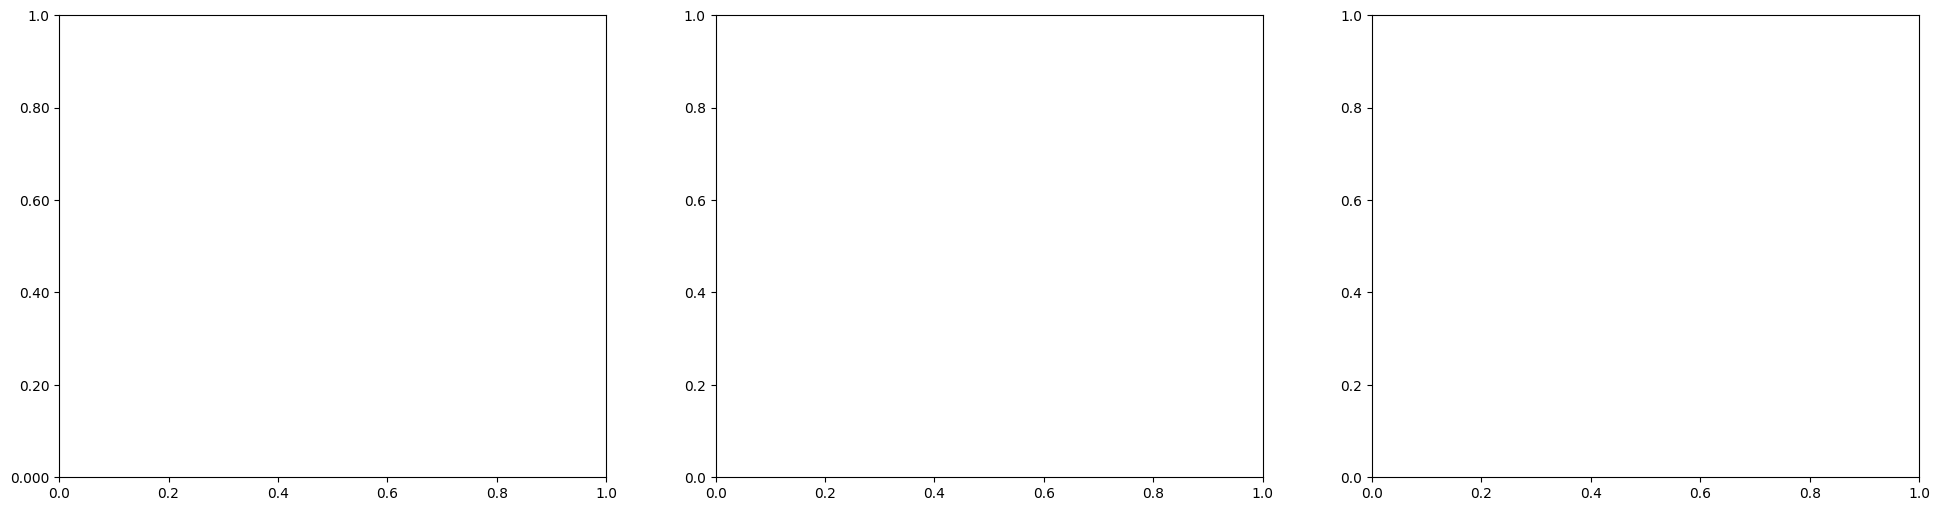

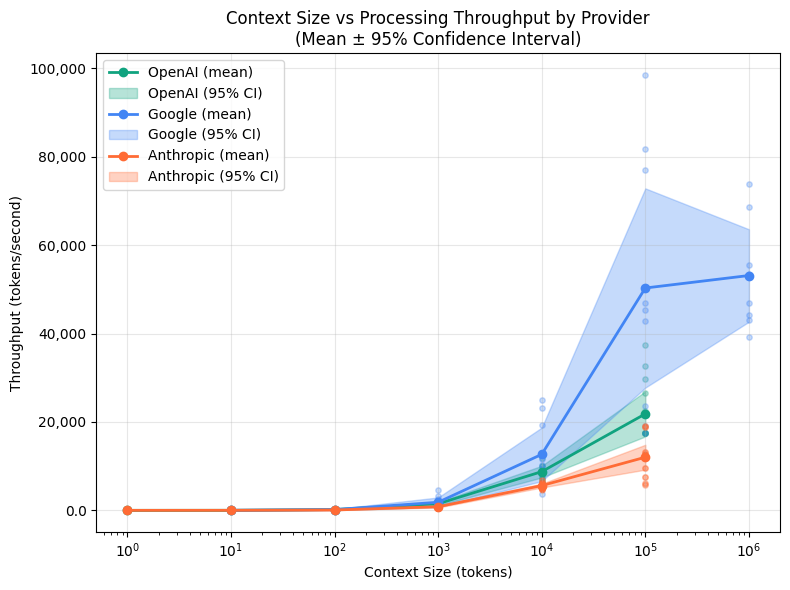


📈 Performance Summary by Provider:
          time_to_first_token                            tokens_per_second  \
                         mean   std       min        max              mean   
provider                                                                     
Anthropic            2.930654  3.71  0.570958  17.384121           3195.60   
Google               4.139341  6.89  0.210779   25.55212          19051.11   
OpenAI               1.630726  1.85  0.414115   7.984493           5866.91   

                                    model_name  
                std   min       max    nunique  
provider                                        
Anthropic   4977.28  0.57  19069.20          3  
Google     26330.47  4.29  98489.47          3  
OpenAI      8903.13  1.17  37422.13          3  

📊 Sample Sizes by Provider and Context Size:
context_size  1        10       100      1000     10000    100000   1000000
provider                                                                   
Ant

In [15]:
# 📊 Provider-Grouped Performance Visualizations
# Create plots showing context size vs duration and throughput, grouped by AI provider
# with mean lines and 95% confidence intervals
from matplotlib.ticker import FuncFormatter
import numpy as np

from context_is_king import IMG_DIR

print("📊 Creating provider-grouped visualizations with 95% confidence intervals...")

def duration_formatter(x, pos):
    if x >= 1:
        return f'{x:.1f}'      # "2.5" instead of "2.5e+00"
    elif x >= 0.1:
        return f'{x:.2f}'      # "0.25" instead of "2.5e-01" 
    else:
        return f'{x:.3f}'      # "0.025" instead of "2.5e-02"
    
def throughput_formatter(x, pos):
    if x >= 10000:
        return f'{x:,.0f}'     # "50,000" instead of "5e+04"
    elif x >= 1000:
        return f'{x:.0f}'      # "5000" instead of "5e+03"
    elif x >= 100:
        return f'{x:.0f}'      # "500" instead of "5e+02"
    else:
        return f'{x:.1f}'      # "50.5" instead of "5.05e+01"
# Load experiment data
try:
    # results, analyzer = experiment.load_experiment("full_experiment", with_analyzer=True)
    df = analyzer.df.copy()
    df.loc[df['time_to_first_token'].isna(), 'time_to_first_token'] = df.loc[df['time_to_first_token'].isna(), 'duration_seconds']

    # Filter for successful results only
    df = df[df["success"]].copy()

    # Extract provider from model names
    def get_provider(model_name):
        if "gpt" in model_name.lower():
            return "OpenAI"
        elif "gemini" in model_name.lower():
            return "Google"
        elif "claude" in model_name.lower():
            return "Anthropic"
        else:
            return "Unknown"

    df["provider"] = df["model_name"].apply(get_provider)

    # Function to calculate 95% confidence interval
    from scipy import stats

    def calculate_ci(values, confidence=0.95):
        """Calculate 95% confidence interval for the mean"""
        n = len(values)
        if n < 2:
            return np.mean(values), 0, 0  # No CI for single points
        mean = np.mean(values)
        sem = stats.sem(values)  # Standard error of mean
        ci_range = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
        if np.isnan(ci_range):
            print(ci_range, sem, mean, n, values)
        return mean, mean - ci_range, mean + ci_range

    # Create side-by-side plots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))
    fig, (ax2) = plt.subplots(1, 1, figsize=(8, 6))

    # Define provider colors
    provider_colors = {
        "OpenAI": "#10A37F",  # OpenAI green
        "Google": "#4285F4",  # Google blue
        "Anthropic": "#FF6B35",  # Anthropic orange
    }

    # Calculate mean and 95% CI for each provider at each context size
    provider_stats = []
    for provider in df["provider"].unique():
        for context_size in sorted(df["context_size"].unique()):
            subset = df[(df["provider"] == provider) & (df["context_size"] == context_size)]
            if len(subset) > 0:
                # Duration statistics
                ttft_mean, ttft_lower, ttft_upper = calculate_ci(subset["time_to_first_token"])

                # Throughput statistics
                tp_mean, tp_lower, tp_upper = calculate_ci(subset["tokens_per_second"])

                dur_mean, dur_lower, dur_upper = calculate_ci(subset["duration_seconds"])


                provider_stats.append(
                    {
                        "provider": provider,
                        "context_size": context_size,
                        "duration_mean": dur_mean,
                        "duration_lower": dur_lower,
                        "duration_upper": dur_upper,
                        "throughput_mean": tp_mean,
                        "throughput_lower": tp_lower,
                        "throughput_upper": tp_upper,
                        "n_samples": len(subset),
                        "ttft_mean": ttft_mean,
                        "ttft_lower": ttft_lower,
                        "ttft_upper": ttft_upper
                    }
                )

    provider_stats_df = pd.DataFrame(provider_stats)

    # # Plot 1: Context Size vs Duration by Provider
    # for provider in df["provider"].unique():
    #     provider_data = provider_stats_df[provider_stats_df["provider"] == provider].sort_values("context_size")
    #     color = provider_colors.get(provider, "gray")

    #     # Plot mean line
    #     ax1.loglog(
    #         provider_data["context_size"],
    #         provider_data["duration_mean"],
    #         label=f"{provider} (mean)",
    #         color=color,
    #         linewidth=2,
    #         marker="o",
    #         markersize=6,
    #     )

    #     # Add 95% confidence interval band
    #     # Ensure bounds are positive for log scale
    #     lower_bound = np.maximum(provider_data["duration_lower"], provider_data["duration_mean"] * 0.01)
    #     upper_bound = provider_data["duration_upper"]

    #     ax1.fill_between(
    #         provider_data["context_size"],
    #         lower_bound,
    #         upper_bound,
    #         alpha=0.3,
    #         color=color,
    #         label=f"{provider} (95% CI)",
    #     )

    #     # Add individual data points with transparency
    #     individual_data = df[df["provider"] == provider]
    #     ax1.scatter(individual_data["context_size"], individual_data["duration_seconds"], alpha=0.3, s=15, color=color)

    # ax1.set_xlabel("Context Size (tokens)")
    # ax1.set_ylabel("Duration (seconds)")
    # ax1.set_title("Context Size vs Response Duration by Provider\n(Mean ± 95% Confidence Interval)")
    # ax1.legend()
    # ax1.grid(True, alpha=0.3)

    # Plot 2: Context Size vs Throughput by Provider
    for provider in df["provider"].unique():
        provider_data = provider_stats_df[provider_stats_df["provider"] == provider].sort_values("context_size")
        color = provider_colors.get(provider, "gray")

        # Plot mean line
        ax2.semilogx(
            provider_data["context_size"],
            provider_data["throughput_mean"],
            label=f"{provider} (mean)",
            color=color,
            linewidth=2,
            marker="o",
            markersize=6,
        )

        # Add 95% confidence interval band
        # Ensure bounds are positive
        lower_bound = np.maximum(provider_data["throughput_lower"], 0)
        upper_bound = provider_data["throughput_upper"]

        ax2.fill_between(
            provider_data["context_size"],
            lower_bound,
            upper_bound,
            alpha=0.3,
            color=color,
            label=f"{provider} (95% CI)",
        )

        # Add individual data points with transparency
        individual_data = df[df["provider"] == provider]
        ax2.scatter(individual_data["context_size"], individual_data["tokens_per_second"], alpha=0.3, s=15, color=color)

    ax2.set_xlabel("Context Size (tokens)")
    ax2.set_ylabel("Throughput (tokens/second)")
    ax2.set_title("Context Size vs Processing Throughput by Provider\n(Mean ± 95% Confidence Interval)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)


    # # Plot 3: ttft vs Throughput by Provider
    # for provider in df["provider"].unique():
    #     provider_data = provider_stats_df[provider_stats_df["provider"] == provider].sort_values("context_size")
    #     color = provider_colors.get(provider, "gray")

    #     # Plot mean line
    #     ax3.semilogx(
    #         provider_data["context_size"],
    #         provider_data["ttft_mean"],
    #         label=f"{provider} (mean)",
    #         color=color,
    #         linewidth=2,
    #         marker="o",
    #         markersize=6,
    #     )

    #     # Add 95% confidence interval band
    #     # Ensure bounds are positive
    #     lower_bound = np.maximum(provider_data["ttft_lower"], 0)
    #     upper_bound = provider_data["ttft_upper"]

    #     ax3.fill_between(
    #         provider_data["context_size"],
    #         lower_bound,
    #         upper_bound,
    #         alpha=0.3,
    #         color=color,
    #         label=f"{provider} (95% CI)",
    #     )

    #     # Add individual data points with transparency
    #     individual_data = df[df["provider"] == provider]
    #     ax2.scatter(individual_data["context_size"], individual_data["time_to_first_token"], alpha=0.3, s=15, color=color)

        


    # ax3.set_xlabel("Context Size (tokens)")
    # ax3.set_ylabel("Time to first token (Seconds)")
    # ax3.set_title("Context Size vs Time-to-First-Token\n(Mean ± 95% Confidence Interval)")
    # ax3.legend()
    # ax3.grid(True, alpha=0.3)

    ax1.yaxis.set_major_formatter(FuncFormatter(duration_formatter))
    ax2.yaxis.set_major_formatter(FuncFormatter(throughput_formatter))

    plt.tight_layout()
    # plt.savefig(f'{IMG_DIR}/ttft_per_provider_and_throughput.png')
    # plt.savefig(f'{IMG_DIR}/throughput_per_provider.png')
    # ax1_extent = ax1.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    # ax2_extent = ax2.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    # ax3_extent = ax3.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

    # plt.savefig(f'{IMG_DIR}/total_duration_per_provider.png', bbox_inches=ax1_extent)
    # plt.savefig(f'{IMG_DIR}/throughput_per_provider.png', bbox_inches=ax2_extent)
    # plt.savefig(f'{IMG_DIR}/ttft_per_provider.png', bbox_inches=ax3_extent)
    plt.show()

    # Print summary statistics by provider
    print(f"\n📈 Performance Summary by Provider:")
    summary = (
        df.groupby("provider")
        .agg(
            {
                "time_to_first_token": ["mean", "std", "min", "max"],
                "tokens_per_second": ["mean", "std", "min", "max"],
                "model_name": "nunique",
            }
        )
        .round(2)
    )

    print(summary)

    # Print confidence interval summary
    print(f"\n📊 Sample Sizes by Provider and Context Size:")
    sample_sizes = df.groupby(["provider", "context_size"]).size().unstack(fill_value=0)
    print(sample_sizes)

    print(f"\n💡 95% Confidence Intervals show where we're 95% confident the true mean lies.")
    print(f"   Narrower bands = more precise estimates (more data or less variability)")

except FileNotFoundError as e:
    print(f"❌ Could not load experiment data: {e}")
except Exception as e:
    print(f"❌ Error creating visualizations: {e}")
    import traceback

    traceback.print_exc()

<Axes: xlabel='response_tokens', ylabel='Count'>

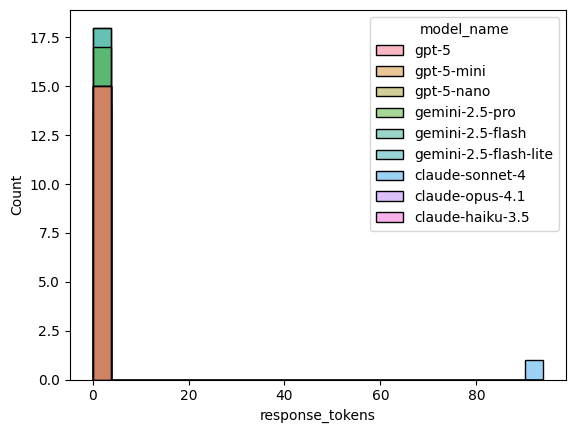

In [72]:
import seaborn as sns

sns.histplot(df, x='response_tokens', hue='model_name')

In [ ]:
x_values = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]

📈 Creating scaling relationships reference plots...


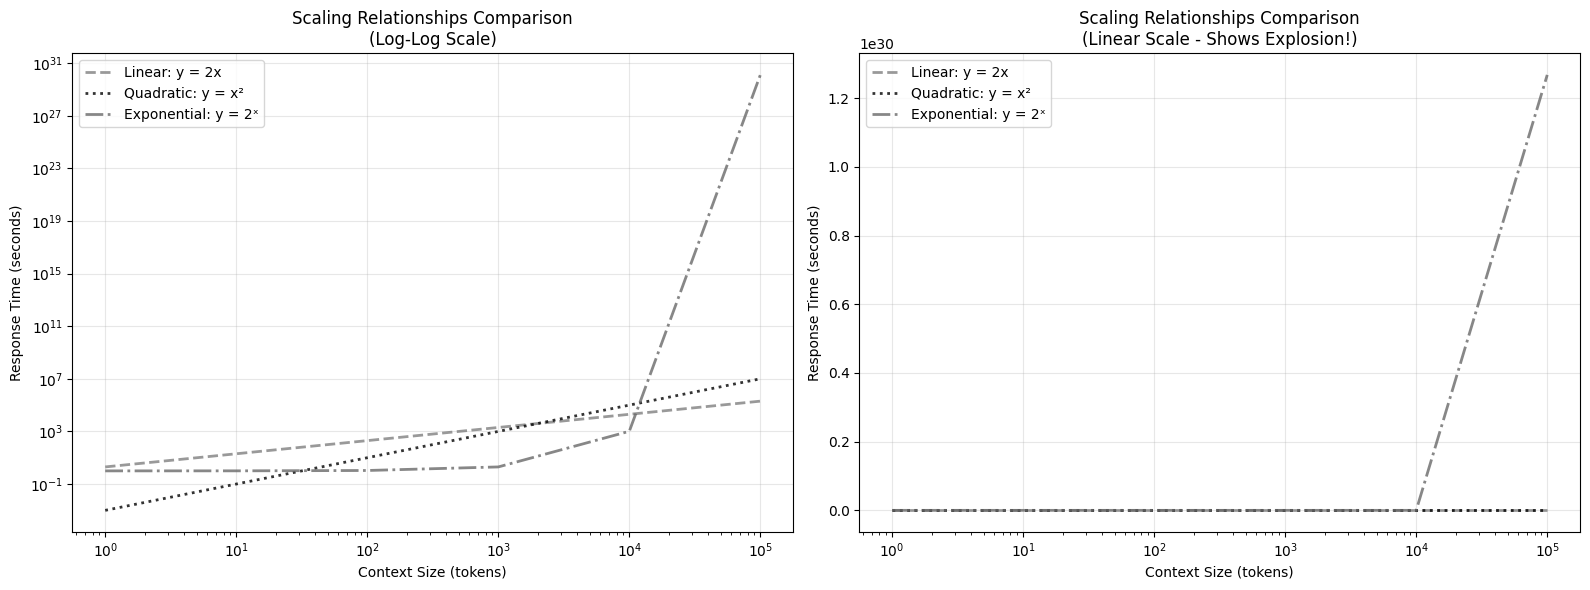


📊 Scaling Relationships Comparison:
Context Size Linear (2x)     Quadratic (x²)     Exponential (2ˣ)    
----------------------------------------------------------------------
1            2.000000        0.001              1.000693            
10           20.000000       0.100              1.006956            
100          200.000000      10.000             1.071773            
1,000        2000.000000     1000.000           2.000000            
10,000       20000.000000    100000.000         1024.000000         
100,000      200000.000000   10000000.000       1267650600228229401496703205376.000000

💡 Scaling Behavior:
🟢 Linear (2x): Response time grows proportionally with context size
🟡 Quadratic (x²): Response time grows with square of context size - EXPLODES!
🔴 Exponential (2ˣ): Response time doubles with each unit increase - COMPLETELY EXPLODES!

🎯 Real LLMs show sub-linear scaling (much better than any of these!)
   This shows why efficient algorithms and architectures matter s

In [ ]:
print("📈 Creating scaling relationships reference plots...")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Create x-axis values - use actual token counts, not normalized nonsense
x_values = np.array([1, 10, 100, 1000, 10000, 100_000])  # Stop before 1M to keep expo sane

# Define scaling functions with simple coefficients - let them explode!
base_time = 1  # 1ms base time

# Linear: y = 2x
y_linear = base_time * 2 * x_values

# Quadratic: y = x^2
y_quadratic = base_time * (x_values ** 2)  # Divide by 1000 to keep reasonable

# Exponential: y = 2^(x/scaling_factor) - scale x down so it doesn't immediately explode
# scaling_factor = 1000  # Scale down x for exponential to show growth pattern
# y_exponential = base_time * (2 ** (x_values / scaling_factor))

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define colors for consistency
colors = {
    'linear': '#10A37F',      # OpenAI green
    'quadratic': '#FF6B35',   # Anthropic orange  
    'exponential': '#DC2626'  # Red for exponential
}

# Plot 1: Log y-axis
ax1.loglog(x_values, y_linear, '--', linewidth=2, markersize=6,
            label='Linear: y = 2x', color="gray", alpha=0.8)
ax1.loglog(x_values, y_quadratic, ':', linewidth=2, markersize=6,
            label='Quadratic: y = x²', color="black", alpha=0.8)
# ax1.loglog(x_values, y_exponential, linestyle='dashdot', linewidth=2, markersize=6,
#             label='Exponential: y = 2ˣ', color="dimgrey", alpha=0.8)

ax1.set_xlabel('Context Size (tokens)')
ax1.set_ylabel('Response Time (seconds)')
ax1.set_title('Scaling Relationships Comparison\n(Log-Log Scale)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Format y-axis for log plot
def duration_formatter_log(x, pos):
    if x >= 1000:
        return f'{x:,.0f}'
    elif x >= 1:
        return f'{x:.1f}'
    elif x >= 0.001:
        return f'{x:.3f}'
    else:
        return f'{x:.1e}'

# ax1.yaxis.set_major_formatter(FuncFormatter(duration_formatter_log))

# Plot 2: Linear y-axis - this will show the explosion clearly
ax2.semilogx(x_values, y_linear, "--", linewidth=2, markersize=6,
            label='Linear: y = 2x', color="gray", alpha=0.8)
ax2.semilogx(x_values, y_quadratic, ':', linewidth=2, markersize=6,
            label='Quadratic: y = x²', color="black", alpha=0.8)
# ax2.semilogx(x_values, y_exponential, linestyle='dashdot', linewidth=2, markersize=6,
#             label='Exponential: y = 2ˣ', color="dimgrey", alpha=0.8)
# ax2.plot(context_range, linear_scaling, "--", color="gray", alpha=0.7, linewidth=2, label="Linear (2x)")
# ax2.plot(context_range, quadratic_scaling, ":", color="black", alpha=0.7, linewidth=2, label="Quadratic (x²)")
# ax2.plot(context_range, exponential_scaling, linestyle="dashdot", color="dimgrey", alpha=0.7, linewidth=2, label="Exponential (2ˣ)")


ax2.set_xlabel('Context Size (tokens)')
ax2.set_ylabel('Response Time (seconds)')
ax2.set_title('Scaling Relationships Comparison\n(Linear Scale - Shows Explosion!)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Format y-axis for linear plot
# ax2.yaxis.set_major_formatter(FuncFormatter(duration_formatter_log))

plt.tight_layout()
# plt.savefig(IMG_DIR / 'linear_scaling_example.png')
# plt.savefig(IMG_DIR / 'linear_quadratic_scaling_example.png')
plt.savefig(IMG_DIR / 'all_scaling_example.png')
plt.show()

# Print scaling comparison at key points
print(f"\n📊 Scaling Relationships Comparison:")
print(f"{'Context Size':<12} {'Linear (2x)':<15} {'Quadratic (x²)':<18} {'Exponential (2ˣ)':<20}")
print("-" * 70)

for x in x_values:
    linear_val = base_time * 2 * x
    quad_val = base_time * (x ** 2) / 1000
    exp_val = base_time * (2 ** (x / scaling_factor))

    print(f"{x:<12,} {linear_val:<15.6f} {quad_val:<18.3f} {exp_val:<20.6f}")

print(f"\n💡 Scaling Behavior:")
print(f"🟢 Linear (2x): Response time grows proportionally with context size")
print(f"🟡 Quadratic (x²): Response time grows with square of context size - EXPLODES!")
print(f"🔴 Exponential (2ˣ): Response time doubles with each unit increase - COMPLETELY EXPLODES!")
print(f"\n🎯 Real LLMs show sub-linear scaling (much better than any of these!)")
print(f"   This shows why efficient algorithms and architectures matter so much.")

📊 Fitting second-order polynomials to provider scaling data...


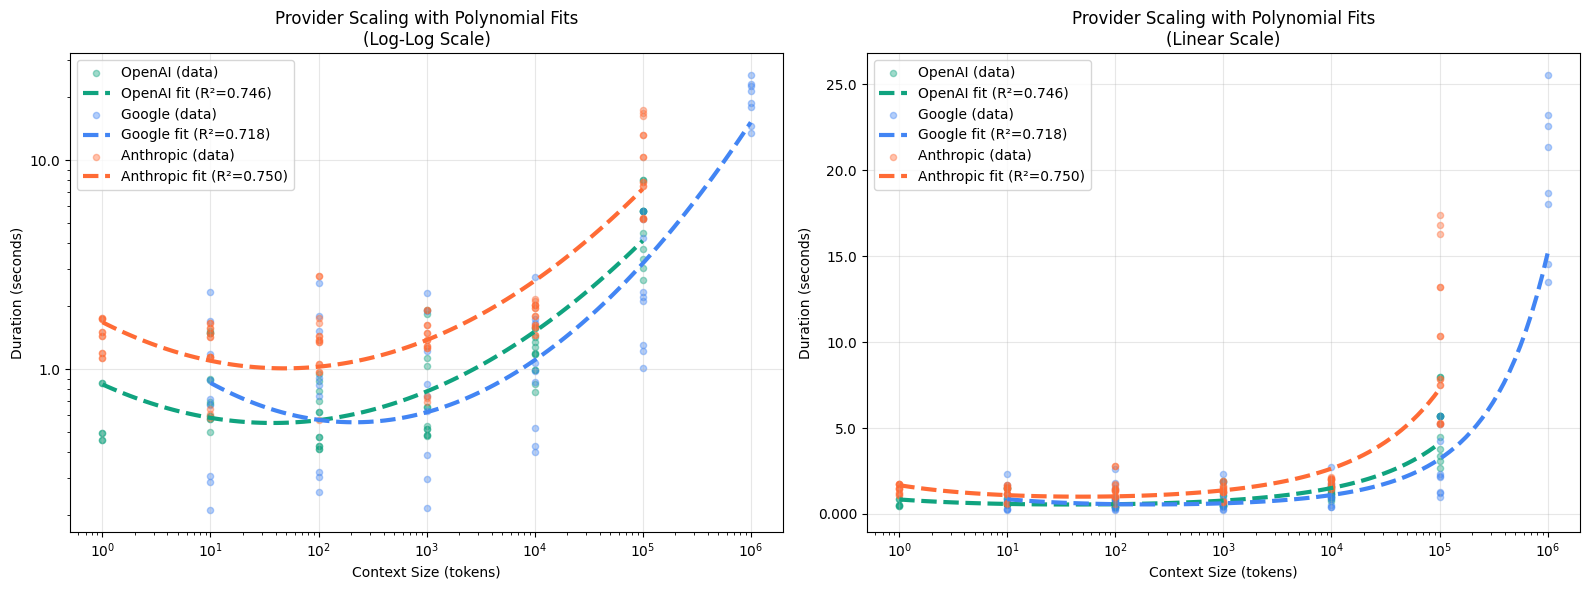

\n📈 Second-Order Polynomial Fits (in log space):
Model: log(duration) = a*log(context)² + b*log(context) + c
----------------------------------------------------------------------
OpenAI:
  Equation: log(y) = 0.0744*log(x)² + -0.2344*log(x) + -0.0734
  R² Score: 0.7457 (Fair fit)
  Scaling: Super-linear (worsening with size)

Google:
  Equation: log(y) = 0.1066*log(x)² + -0.4966*log(x) + 0.3238
  R² Score: 0.7180 (Fair fit)
  Scaling: Super-linear (worsening with size)

Anthropic:
  Equation: log(y) = 0.0780*log(x)² + -0.2624*log(x) + 0.2241
  R² Score: 0.7502 (Fair fit)
  Scaling: Super-linear (worsening with size)

💡 Interpretation:
• Quadratic coefficient (a) > 0: Performance degrades faster at larger contexts
• Quadratic coefficient (a) < 0: Performance improves (efficiency gains) at larger contexts
• Linear coefficient (b): Primary scaling relationship
• R² closer to 1.0: Better polynomial fit to the data


In [85]:
# 📊 Polynomial Fitting to Provider Scaling Data
# Fit second-order polynomials to each provider's duration vs context size relationship

print("📊 Fitting second-order polynomials to provider scaling data...")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

try:
    # Load experiment data
    # results, analyzer = experiment.load_experiment("full_experiment", with_analyzer=True)
    # df = analyzer.df.copy()

    # Filter for successful results only
    df = df[df["success"]].copy()

    # Extract provider from model names
    def get_provider(model_name):
        if "gpt" in model_name.lower():
            return "OpenAI"
        elif "gemini" in model_name.lower():
            return "Google"
        elif "claude" in model_name.lower():
            return "Anthropic"
        else:
            return "Unknown"

    df["provider"] = df["model_name"].apply(get_provider)

    # Define provider colors
    provider_colors = {
        "OpenAI": "#10A37F",  # OpenAI green
        "Google": "#4285F4",  # Google blue
        "Anthropic": "#FF6B35",  # Anthropic orange
    }

    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Store polynomial fits for analysis
    polynomial_fits = {}

    for provider in df["provider"].unique():
        provider_data = df[df["provider"] == provider].copy()
        color = provider_colors.get(provider, "gray")

        # Get context sizes and durations
        X = provider_data["context_size"].values
        y = provider_data["duration_seconds"].values

        # Transform to log space for fitting (common for scaling analysis)
        log_X = np.log10(X).reshape(-1, 1)
        log_y = np.log10(y)

        # Fit second-order polynomial: log(y) = a*log(x)^2 + b*log(x) + c
        poly_features = PolynomialFeatures(degree=2, include_bias=True)
        X_poly = poly_features.fit_transform(log_X)

        poly_reg = LinearRegression()
        poly_reg.fit(X_poly, log_y)

        # Calculate R² score
        y_pred = poly_reg.predict(X_poly)
        r2 = r2_score(log_y, y_pred)

        # Store fit results
        coefficients = poly_reg.coef_
        intercept = poly_reg.intercept_
        polynomial_fits[provider] = {"coefficients": coefficients, "intercept": intercept, "r2": r2}

        # Create smooth curve for plotting
        x_smooth = np.logspace(np.log10(X.min()), np.log10(X.max()), 100)
        log_x_smooth = np.log10(x_smooth).reshape(-1, 1)
        X_smooth_poly = poly_features.transform(log_x_smooth)
        log_y_smooth = poly_reg.predict(X_smooth_poly)
        y_smooth = 10**log_y_smooth

        # Plot 1: Log-log scale with polynomial fit
        ax1.scatter(X, y, alpha=0.4, s=20, color=color, label=f"{provider} (data)")
        ax1.loglog(x_smooth, y_smooth, "--", linewidth=3, color=color, label=f"{provider} fit (R²={r2:.3f})")

        # Plot 2: Linear scale with polynomial fit
        ax2.scatter(X, y, alpha=0.4, s=20, color=color, label=f"{provider} (data)")
        ax2.semilogx(x_smooth, y_smooth, "--", linewidth=3, color=color, label=f"{provider} fit (R²={r2:.3f})")

    # Format Plot 1 (Log-log)
    ax1.set_xlabel("Context Size (tokens)")
    ax1.set_ylabel("Duration (seconds)")
    ax1.set_title("Provider Scaling with Polynomial Fits\n(Log-Log Scale)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Custom formatter for duration
    def duration_formatter(x, pos):
        if x >= 1:
            return f"{x:.1f}"
        elif x >= 0.1:
            return f"{x:.2f}"
        else:
            return f"{x:.3f}"

    ax1.yaxis.set_major_formatter(FuncFormatter(duration_formatter))

    # Format Plot 2 (Linear)
    ax2.set_xlabel("Context Size (tokens)")
    ax2.set_ylabel("Duration (seconds)")
    ax2.set_title("Provider Scaling with Polynomial Fits\n(Linear Scale)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.yaxis.set_major_formatter(FuncFormatter(duration_formatter))

    plt.tight_layout()
    plt.savefig(IMG_DIR / 'providers_exp_scaling_fit.png')
    plt.show()

    # Display polynomial equations and fit quality
    print(f"\\n📈 Second-Order Polynomial Fits (in log space):")
    print(f"Model: log(duration) = a*log(context)² + b*log(context) + c")
    print("-" * 70)

    for provider, fit_data in polynomial_fits.items():
        a, b = fit_data["coefficients"][2], fit_data["coefficients"][1]  # quadratic, linear terms
        c = fit_data["intercept"]
        r2 = fit_data["r2"]

        print(f"{provider}:")
        print(f"  Equation: log(y) = {a:.4f}*log(x)² + {b:.4f}*log(x) + {c:.4f}")
        print(
            f"  R² Score: {r2:.4f} ({'Excellent' if r2 > 0.9 else 'Good' if r2 > 0.8 else 'Fair' if r2 > 0.7 else 'Poor'} fit)"
        )

        # Interpret scaling behavior
        if abs(a) < 0.01:
            scaling_type = "Nearly Linear"
        elif a > 0:
            scaling_type = "Super-linear (worsening with size)"
        else:
            scaling_type = "Sub-linear (improving efficiency with size)"
        print(f"  Scaling: {scaling_type}")
        print()

    print(f"💡 Interpretation:")
    print(f"• Quadratic coefficient (a) > 0: Performance degrades faster at larger contexts")
    print(f"• Quadratic coefficient (a) < 0: Performance improves (efficiency gains) at larger contexts")
    print(f"• Linear coefficient (b): Primary scaling relationship")
    print(f"• R² closer to 1.0: Better polynomial fit to the data")

except FileNotFoundError as e:
    print(f"❌ Could not load experiment data: {e}")
except Exception as e:
    print(f"❌ Error fitting polynomials: {e}")
    import traceback

    traceback.print_exc()

In [117]:
provider_data

,model_name,context_size,duration_seconds,tokens_per_second,success,error_message,provider
83,claude-haiku-3.5,10,0.643596,15.537693,True,None,Anthropic
84,claude-haiku-3.5,10,0.612083,16.337655,True,None,Anthropic
85,claude-haiku-3.5,10,0.585391,17.082598,True,None,Anthropic
86,claude-haiku-3.5,100,1.758624,56.862636,True,None,Anthropic
87,claude-haiku-3.5,100,1.660448,60.224716,True,None,Anthropic
88,claude-haiku-3.5,100,0.570958,175.144189,True,None,Anthropic
89,claude-haiku-3.5,1000,0.697121,1434.470909,True,None,Anthropic
90,claude-haiku-3.5,1000,0.724570,1380.129290,True,None,Anthropic
91,claude-haiku-3.5,1000,0.744149,1343.816521,True,None,Anthropic
92,claude-haiku-3.5,10000,2.166840,4615.015251,True,None,Anthropic


📊 Creating provider scaling comparison with theoretical references...


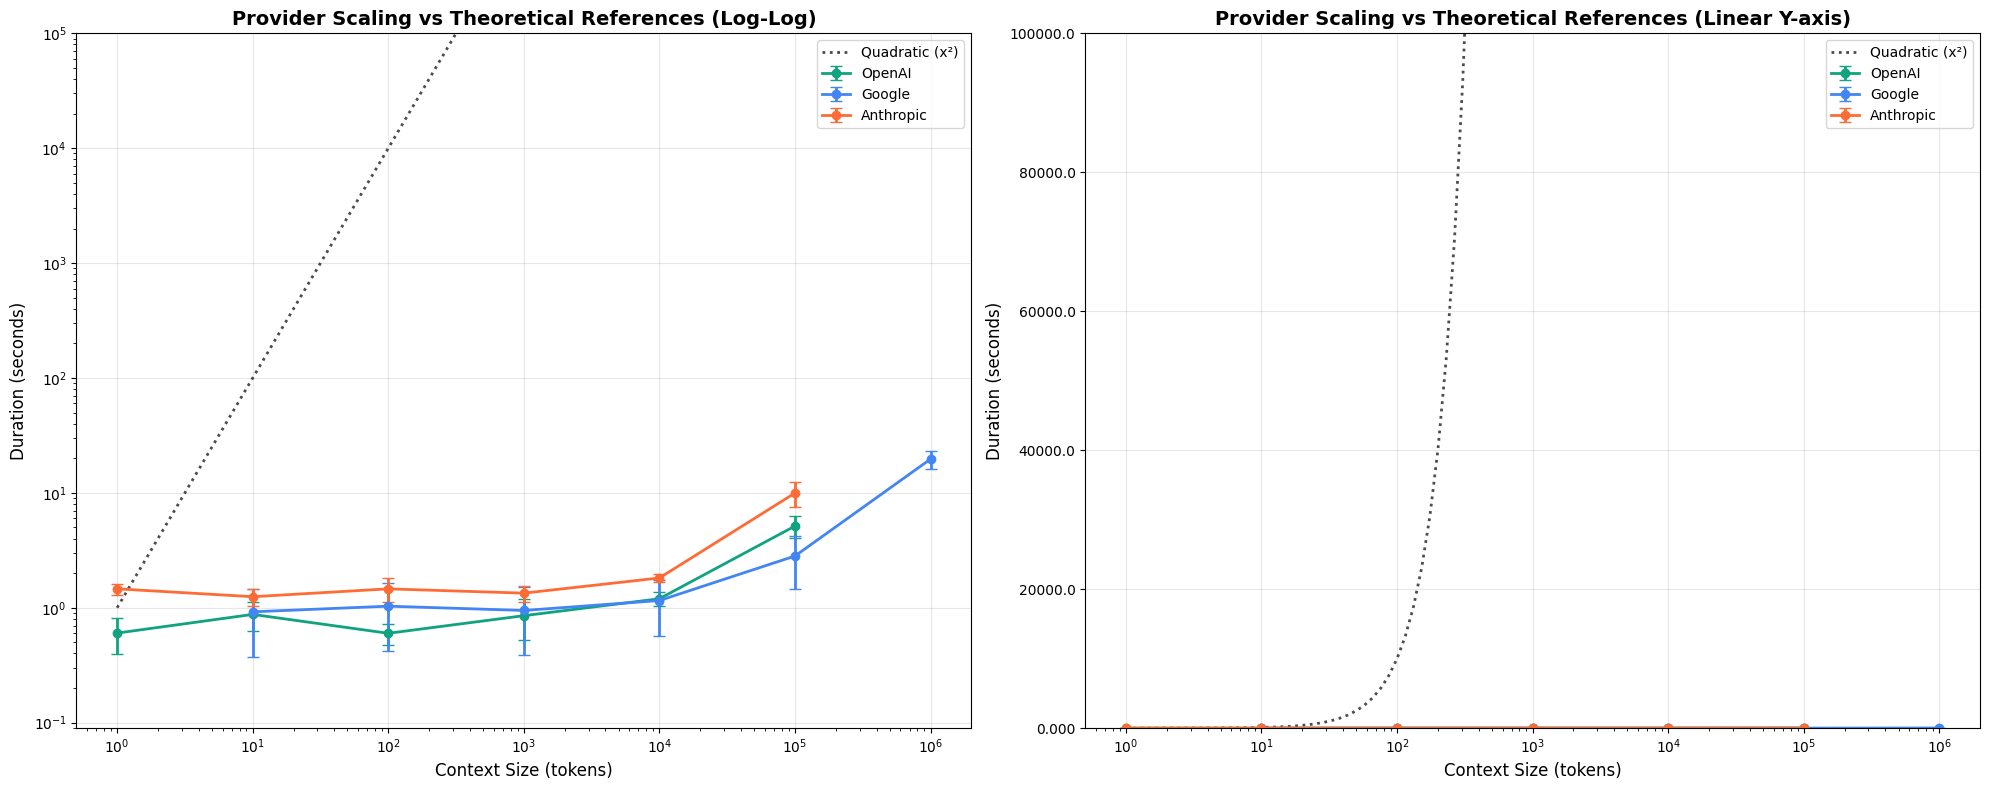

=== Provider vs Theoretical Scaling Analysis ===

Key Observations:
• Linear scaling (gray dashed): Perfect proportionality with context size
• Quadratic scaling (black dotted): Shows x² growth pattern
• Provider performance relative to theoretical baselines:

  OpenAI:
    Actual scaling ratio: 8.5x (1 → 100,000 tokens)
    Linear expectation: 100000.0x
    Quadratic expectation: 10000000000x
    → Sub-linear scaling (better than linear!)

  Google:
    Actual scaling ratio: 21.4x (10 → 1,000,000 tokens)
    Linear expectation: 100000.0x
    Quadratic expectation: 10000000000x
    → Sub-linear scaling (better than linear!)

  Anthropic:
    Actual scaling ratio: 6.8x (1 → 100,000 tokens)
    Linear expectation: 100000.0x
    Quadratic expectation: 10000000000x
    → Sub-linear scaling (better than linear!)



In [17]:
# Provider Scaling with Theoretical Reference Lines
print("📊 Creating provider scaling comparison with theoretical references...")
import numpy as np
y_lim = 100_000

try:
    # Load experiment data
    # results, analyzer = experiment.load_experiment("full_experiment", with_analyzer=True)
    df = analyzer.df.copy()

    # Filter for successful results only
    df = df[df["success"]].copy()

    # Extract provider from model names
    def get_provider(model_name):
        if "gpt" in model_name.lower():
            return "OpenAI"
        elif "gemini" in model_name.lower():
            return "Google"
        elif "claude" in model_name.lower():
            return "Anthropic"
        else:
            return "Unknown"

    df["provider"] = df["model_name"].apply(get_provider)

    # Calculate mean and 95% CI for each provider-context combination
    from scipy import stats

    def calculate_ci(values, confidence=0.95):
        """Calculate confidence interval for the mean using t-distribution."""
        n = len(values)
        if n < 2:
            return np.mean(values), 0
        mean = np.mean(values)
        sem = stats.sem(values)
        ci_range = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
        return mean, ci_range

    # Group data by provider and context size
    provider_data = {}
    for provider in df["provider"].unique():
        if provider == "Unknown":
            continue

        provider_df = df[df["provider"] == provider]
        context_sizes = sorted(provider_df["context_size"].unique())
        durations = []
        ci_ranges = []

        for context_size in context_sizes:
            context_data = provider_df[provider_df["context_size"] == context_size]["duration_seconds"]
            mean_duration, ci_range = calculate_ci(context_data.values)
            durations.append(mean_duration)
            ci_ranges.append(ci_range)

        provider_data[provider] = {"context_sizes": context_sizes, "durations": durations, "ci_ranges": ci_ranges}

    # Create side-by-side plots
    fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(20, 8))

    # Define provider colors
    provider_colors = {
        "OpenAI": "#10a37f",  # OpenAI green
        "Google": "#4285f4",  # Google blue
        "Anthropic": "#ff6b35",  # Anthropic orange
    }

    # Linear y-axis plot
    for provider in provider_data.keys():
        data = provider_data[provider]
        context_sizes = data["context_sizes"]
        durations = data["durations"]
        ci_ranges = data["ci_ranges"]

        ax1.errorbar(
            context_sizes,
            durations,
            yerr=ci_ranges,
            marker="o",
            linewidth=2,
            markersize=6,
            capsize=4,
            label=f"{provider}",
            color=provider_colors[provider],
        )

    # Add theoretical scaling lines
    context_range = np.logspace(0, 6, 100)  # 1 to 1M tokens

    # Linear scaling: 2x (normalize to start at similar point)
    base_duration = 1.0  # Base duration at 1 token
    # linear_scaling = base_duration * (context_range / 1)  # Linear with context
    # ax1.plot(context_range, linear_scaling, "--", color="gray", alpha=0.7, linewidth=2, label="Linear (2x)")

    # Quadratic scaling: x²
    quadratic_scaling = base_duration * (context_range) ** 2  # Scaled down for visibility
    ax1.plot(context_range, quadratic_scaling, ":", color="black", alpha=0.7, linewidth=2, label="Quadratic (x²)")

    # Exponential: 2ˣ
    # exponential_scaling = base_duration * ( 2 ** (context_range / 1000))  # Scaled down for visibility
    # ax1.plot(context_range, exponential_scaling, linestyle="dashdot", color="dimgrey", alpha=0.7, linewidth=2, label="Exponential (2ˣ)")

    ax1.set_xscale("log")
    ax1.set_xlabel("Context Size (tokens)", fontsize=12)
    ax1.set_ylabel("Duration (seconds)", fontsize=12)
    ax1.set_title("Provider Scaling vs Theoretical References (Linear Y-axis)", fontsize=14, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, y_lim)
    ax1.legend(fontsize=10)

    # Format y-axis to avoid scientific notation
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(duration_formatter))

    # Log-log plot
    for provider in provider_data.keys():
        data = provider_data[provider]
        context_sizes = data["context_sizes"]
        durations = data["durations"]
        ci_ranges = data["ci_ranges"]

        ax2.errorbar(
            context_sizes,
            durations,
            yerr=ci_ranges,
            marker="o",
            linewidth=2,
            markersize=6,
            capsize=4,
            label=f"{provider}",
            color=provider_colors[provider],
        )

    # Add theoretical scaling lines (log-log space)
    # ax2.plot(context_range, linear_scaling, "--", color="gray", alpha=0.7, linewidth=2, label="Linear (2x)")
    ax2.plot(context_range, quadratic_scaling, ":", color="black", alpha=0.7, linewidth=2, label="Quadratic (x²)")
    # ax2.plot(context_range, exponential_scaling, linestyle="dashdot", color="dimgrey", alpha=0.7, linewidth=2, label="Exponential (2ˣ)")

    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel("Context Size (tokens)", fontsize=12)
    ax2.set_ylabel("Duration (seconds)", fontsize=12)
    ax2.set_title("Provider Scaling vs Theoretical References (Log-Log)", fontsize=14, fontweight="bold")
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, y_lim)
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(IMG_DIR / 'companies_vs_example_scaling.png')
    plt.show()

    # Analysis summary
    print("=== Provider vs Theoretical Scaling Analysis ===")
    print()
    print("Key Observations:")
    print("• Linear scaling (gray dashed): Perfect proportionality with context size")
    print("• Quadratic scaling (black dotted): Shows x² growth pattern")
    print("• Provider performance relative to theoretical baselines:")
    print()

    for provider in provider_data.keys():
        data = provider_data[provider]
        if len(data["context_sizes"]) >= 2:
            # Calculate actual scaling between first and last points
            first_context, last_context = data["context_sizes"][0], data["context_sizes"][-1]
            first_duration, last_duration = data["durations"][0], data["durations"][-1]

            actual_ratio = last_duration / first_duration
            context_ratio = last_context / first_context

            # Compare to theoretical
            linear_ratio = context_ratio  # Linear scaling
            quadratic_ratio = context_ratio**2  # Quadratic scaling

            print(f"  {provider}:")
            print(f"    Actual scaling ratio: {actual_ratio:.1f}x ({first_context:,} → {last_context:,} tokens)")
            print(f"    Linear expectation: {linear_ratio:.1f}x")
            print(f"    Quadratic expectation: {quadratic_ratio:.0f}x")

            if actual_ratio < linear_ratio:
                print(f"    → Sub-linear scaling (better than linear!)")
            elif actual_ratio < quadratic_ratio:
                print(f"    → Between linear and quadratic")
            else:
                print(f"    → Super-quadratic scaling")
            print()

except FileNotFoundError as e:
    print(f"❌ Could not load experiment data: {e}")
except Exception as e:
    print(f"❌ Error creating provider comparison: {e}")
    import traceback

    traceback.print_exc()